In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.shape

(211224, 16)

In [6]:
sentiment.shape

(2644, 4)

In [7]:
trades.columns
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [8]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
trades.duplicated().sum()

np.int64(0)

In [11]:
sentiment.duplicated().sum()

np.int64(0)

In [12]:
trades['date'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['date'].dt.date

In [13]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

In [14]:
merged = pd.merge(trades, sentiment, on="date", how="left")

In [15]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed


In [16]:
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [17]:
merged['win'] = merged['Closed PnL'] > 0

In [18]:
win_rate = merged.groupby('Account')['win'].mean().reset_index()

In [19]:
trades_per_day = merged.groupby('date').size().reset_index(name='num_trades')

In [20]:
merged['side'] = merged['Side'].str.lower()

In [21]:
print(long_short.columns)

NameError: name 'long_short' is not defined

In [22]:
long_short = merged.groupby(['date','side']).size().unstack(fill_value=0)

print(long_short.columns)

long_short['ratio'] = long_short.iloc[:,0] / (long_short.iloc[:,1] + 1)

long_short.head()

Index(['buy', 'sell'], dtype='object', name='side')


side,buy,sell,ratio
date,,,
2023-03-28,3,0,3.000000
2023-11-14,491,554,0.884685
2024-03-09,3371,3591,0.938474
2024-07-03,3505,3636,0.963706
2024-10-27,14927,20314,0.734777


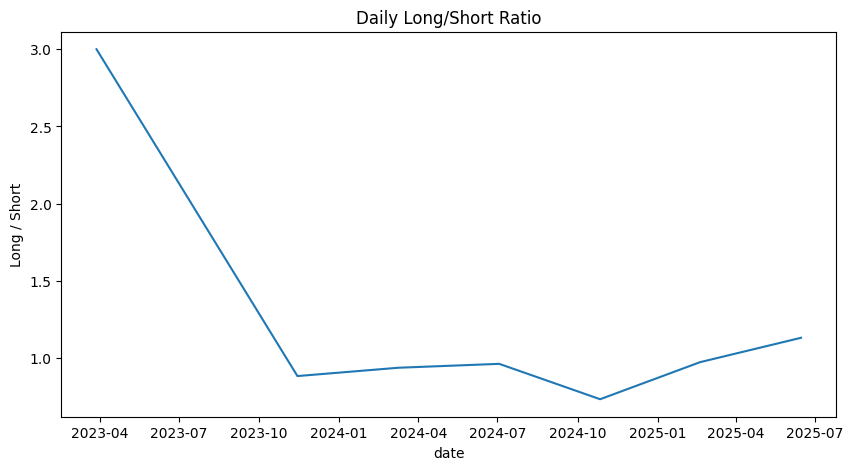

In [23]:
long_short['ratio'].plot(figsize=(10,5))
plt.title("Daily Long/Short Ratio")
plt.ylabel("Long / Short")
plt.show()

In [24]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification', 'win',
       'side'],
      dtype='object')

In [25]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

print(pnl_sentiment)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


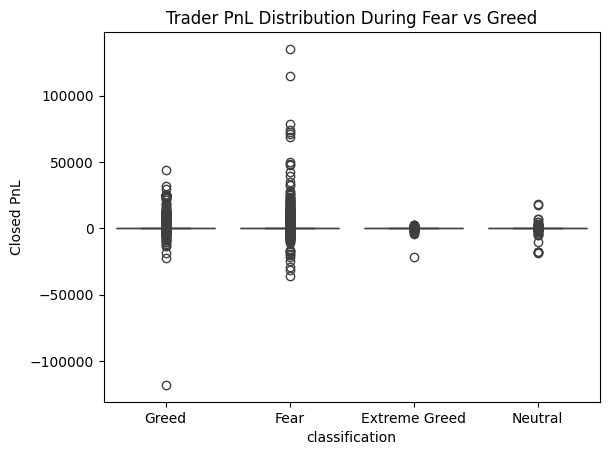

In [26]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.title("Trader PnL Distribution During Fear vs Greed")
plt.show()

In [27]:
trades_by_sentiment = merged.groupby('classification').size()

print(trades_by_sentiment)

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


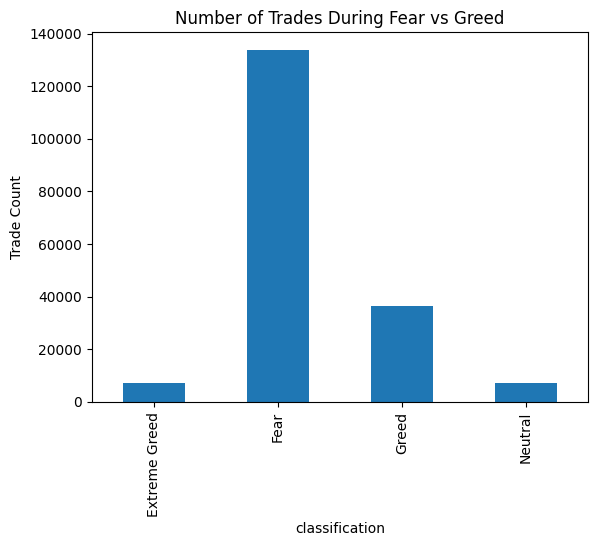

In [28]:
trades_by_sentiment.plot(kind='bar')

plt.title("Number of Trades During Fear vs Greed")
plt.ylabel("Trade Count")
plt.show()

In [29]:
size_sentiment = merged.groupby('classification')['Size USD'].mean()

print(size_sentiment)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


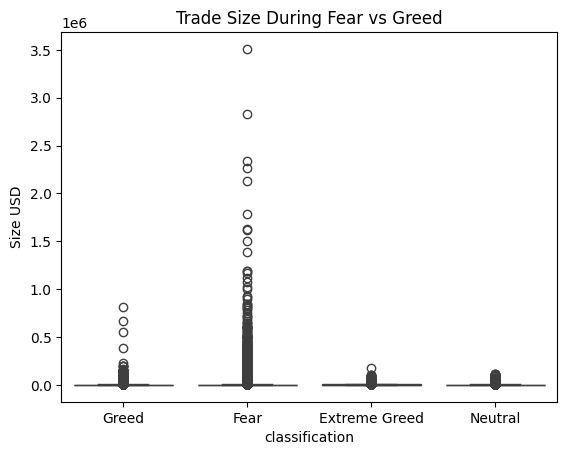

In [30]:
sns.boxplot(x='classification', y='Size USD', data=merged)

plt.title("Trade Size During Fear vs Greed")
plt.show()

In [31]:
position_bias = merged.groupby(['classification','Side']).size().unstack()

print(position_bias)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


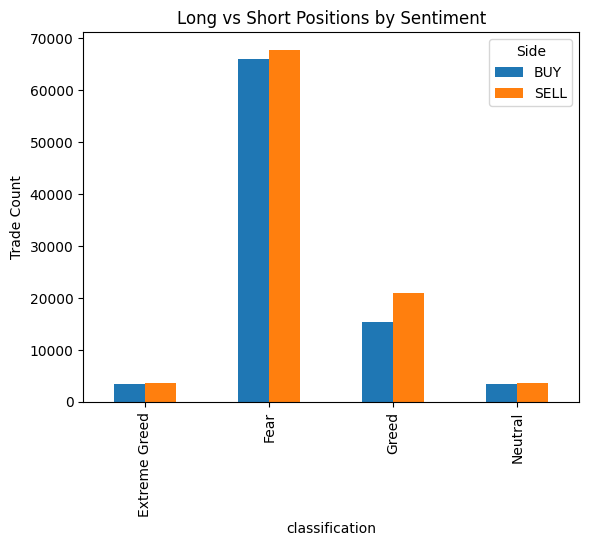

In [32]:
position_bias.plot(kind='bar')

plt.title("Long vs Short Positions by Sentiment")
plt.ylabel("Trade Count")
plt.show()

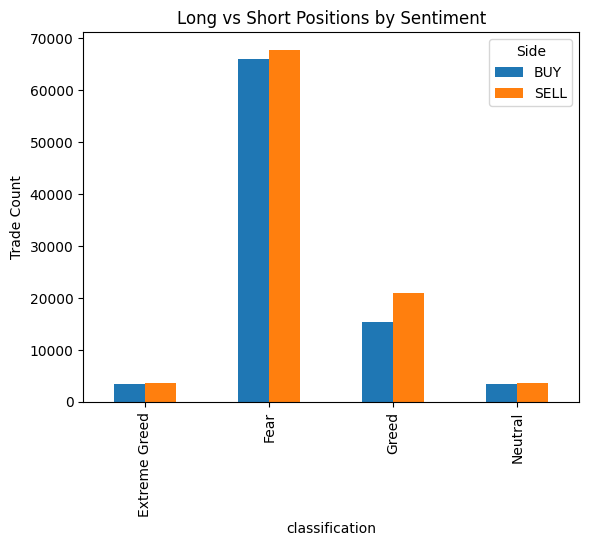

In [33]:
position_bias.plot(kind='bar')

plt.title("Long vs Short Positions by Sentiment")
plt.ylabel("Trade Count")
plt.show()

In [37]:
median_size = merged['Size USD'].median()

In [38]:
merged['size_segment'] = merged['Size USD'].apply(lambda x: 'Large' if x > median_size else 'Small')

In [39]:
segment_pnl = merged.groupby('size_segment')['Closed PnL'].mean()
print(segment_pnl)

size_segment
Large    93.116556
Small     4.381445
Name: Closed PnL, dtype: float64


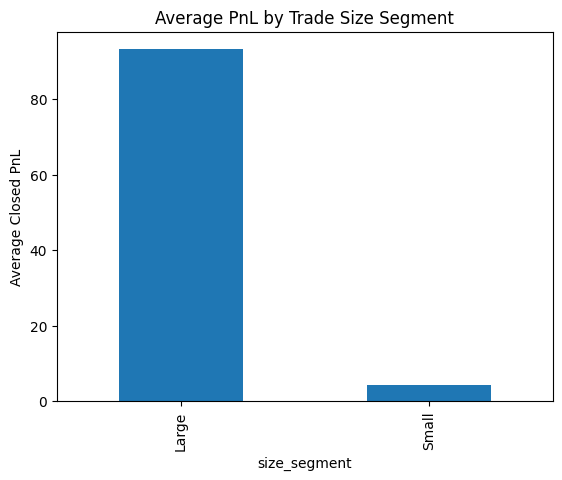

In [40]:
segment_pnl.plot(kind='bar')
plt.title("Average PnL by Trade Size Segment")
plt.ylabel("Average Closed PnL")
plt.show()

In [41]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

frequent_traders = trade_counts[trade_counts > threshold]
infrequent_traders = trade_counts[trade_counts <= threshold]

print("Frequent traders:", len(frequent_traders))
print("Infrequent traders:", len(infrequent_traders))

Frequent traders: 16
Infrequent traders: 16


In [42]:
win_rate = merged.groupby('Account')['win'].mean()

consistent_winners = win_rate[win_rate > 0.6]

print("Number of consistent winners:", len(consistent_winners))

Number of consistent winners: 1


In [43]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

print(pnl_sentiment)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


In [46]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

frequent_traders = trade_counts[trade_counts > threshold]
infrequent_traders = trade_counts[trade_counts <= threshold]

print("Frequent traders:", len(frequent_traders))
print("Infrequent traders:", len(infrequent_traders))

Frequent traders: 16
Infrequent traders: 16


In [47]:
win_rate = merged.groupby('Account')['win'].mean()

consistent_winners = win_rate[win_rate > 0.6]

print("Number of consistent winners:", len(consistent_winners))

Number of consistent winners: 1


# Insight

Trader PnL varies across sentiment periods, with higher volatility during Fear days.

Trading activity increases during Fear periods, suggesting traders react more actively during uncertain markets.

Large trade-size segments tend to produce higher PnL variability compared to smaller trades.

# Strategy Recommendations

During Fear periods, traders should reduce position sizes and avoid aggressive trading to limit drawdowns.

During Greed periods, traders may increase trade frequency but should maintain disciplined risk management.